# Colab 1 — VAE Training
**KTH World Model Pipeline**

```
Colab 1 (this) → trains VAE v2 → uploads vae_v2.pth to Hugging Face Hub
Colab 2         → downloads VAE → trains ConvLSTM
Colab 3         → downloads VAE → trains Spatial Transformer
Colab 4         → downloads all 3 → evaluation + GIFs
```

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CONFIG — fill these in once, copy to all 4 Colabs
# ══════════════════════════════════════════════════════════════════════════
HF_TOKEN   = #entered
HF_REPO_ID = #entered

# Training config
VAE_EPOCHS  = 75
BATCH_SIZE  = 8
DATA_PATH   = '/content/kth_data'
SAVE_PATH   = '/content'           # local Colab storage — no Drive needed
KTH_ACTIONS = ['walking', 'jogging']

In [ ]:
# ── Install deps ──────────────────────────────────────────────────────────
!pip install torch torchvision scikit-image imageio tqdm lpips Pillow huggingface_hub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.2 MB/s eta 0:00:00


In [ ]:
# ── Extra deps for improved VAE ───────────────────────────────────────────
!pip install pytorch-msssim -q


In [ ]:
import os, glob, random, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import lpips

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(DATA_PATH, exist_ok=True)

lpips_fn = lpips.LPIPS(net='alex').to(device)
for p in lpips_fn.parameters(): p.requires_grad = False
print('LPIPS ready.')

PyTorch 2.10.0+cu128 | Device: cuda
GPU: Tesla T4
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 152MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS ready.


In [ ]:
# ── Download KTH (walking + jogging only, ~180MB) ─────────────────────────
KTH_BASE_URL = 'https://www.csc.kth.se/cvap/actions/'

def download_kth_lean(actions, data_path):
    import requests, zipfile
    for action in actions:
        zip_path     = os.path.join(data_path, f'{action}.zip')
        extract_path = os.path.join(data_path, action)
        if os.path.exists(extract_path) and len(os.listdir(extract_path)) > 0:
            print(f'  {action} already exists — skipping')
            continue
        print(f'  Downloading {action}...')
        with requests.get(KTH_BASE_URL + f'{action}.zip', stream=True) as r:
            r.raise_for_status()
            with open(zip_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        print(f'  Extracting {action}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(data_path)
        os.remove(zip_path)
        print(f'  {action} done.')

download_kth_lean(KTH_ACTIONS, DATA_PATH)

  Extracting walking...
  walking done.
  Extracting jogging...
  jogging done.


In [ ]:
# ── KTH Dataset ───────────────────────────────────────────────────────────
class KTHDataset(Dataset):
    IMG_SIZE = 64
    SEQ_LEN  = 20

    def __init__(self, data_path, actions, split='train', augment=True):
        self.augment   = augment
        self.sequences = []
        self.transform = T.Compose([
            T.Grayscale(),
            T.Resize((self.IMG_SIZE, self.IMG_SIZE),
                     interpolation=T.InterpolationMode.LANCZOS, antialias=True),
            T.ToTensor(),
        ])
        train_persons = {f'person{i:02d}' for i in range(1, 17)}
        test_persons  = {f'person{i:02d}' for i in range(17, 26)}
        allowed = train_persons if split == 'train' else test_persons

        all_videos = glob.glob(os.path.join(data_path, '*.avi'))
        print(f'Found {len(all_videos)} total videos')

        for vid_file in sorted(all_videos):
            filename = os.path.basename(vid_file).lower()
            if not any(action in filename for action in actions): continue
            person = filename.split('_')[0]
            if person not in allowed: continue
            frames = self._load_video(vid_file)
            for start in range(0, len(frames) - self.SEQ_LEN, self.SEQ_LEN // 2):
                clip = frames[start:start + self.SEQ_LEN]
                if len(clip) == self.SEQ_LEN:
                    self.sequences.append(clip)

        print(f'KTH {split}: {len(self.sequences)} sequences')

    def _load_video(self, path):
        import cv2
        cap = cv2.VideoCapture(path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret: break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            t = self.transform(Image.fromarray(frame))
            t_min, t_max = t.min(), t.max()
            if t_max > t_min:
                t = (t - t_min) / (t_max - t_min)
            frames.append(t)
        cap.release()
        return frames

    def __len__(self): return len(self.sequences)

    def __getitem__(self, idx):
        seq = torch.stack(self.sequences[idx], dim=0)
        if self.augment and random.random() > 0.5:
            seq = torch.flip(seq, dims=[3])
        return seq


train_dataset = KTHDataset(DATA_PATH, KTH_ACTIONS, split='train', augment=True)
test_dataset  = KTHDataset(DATA_PATH, KTH_ACTIONS, split='test',  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches : {len(test_loader)}')

Found 200 total videos
KTH train: 6738 sequences
Found 200 total videos
KTH test: 3885 sequences
Train batches: 843
Test batches : 486


In [ ]:
# ── VAE v2 (Improved) ─────────────────────────────────────────────────────
# Changes vs original:
#   • Residual blocks in encoder + decoder → sharper, more stable features
#   • PixelShuffle upsampling instead of ConvTranspose → eliminates checkerboard
#   • Learnable logvar clamp via softplus → more stable KL
#   • Perceptual + MSE + SSIM combo loss → sharpness boost
#   • Beta annealing: KL starts near 0, ramps up → no posterior collapse

from pytorch_msssim import ssim   # installed in next pip cell; graceful fallback below

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.GroupNorm(8, ch), nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.GroupNorm(8, ch),
        )
        self.act = nn.SiLU()
    def forward(self, x): return self.act(x + self.net(x))


class VAE(nn.Module):
    def __init__(self, latent_channels=128):
        super().__init__()
        self.latent_channels = latent_channels
        lc = latent_channels

        self.encoder = nn.Sequential(
            # 64→32
            nn.Conv2d(1,  32, 4, stride=2, padding=1), nn.SiLU(),
            ResBlock(32),
            # 32→16
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.SiLU(),
            ResBlock(64),
            # 16→8
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.SiLU(),
            ResBlock(128),
            # → mu/logvar map at 8×8
            nn.Conv2d(128, lc * 2, 3, stride=1, padding=1),
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(lc, 128, 3, padding=1), nn.SiLU(),
            ResBlock(128),
            # 8→16  (PixelShuffle: no checkerboard)
            nn.Conv2d(128, 64 * 4, 3, padding=1), nn.PixelShuffle(2), nn.SiLU(),
            ResBlock(64),
            # 16→32
            nn.Conv2d(64, 32 * 4, 3, padding=1), nn.PixelShuffle(2), nn.SiLU(),
            ResBlock(32),
            # 32→64
            nn.Conv2d(32, 16 * 4, 3, padding=1), nn.PixelShuffle(2), nn.SiLU(),
            nn.Conv2d(16, 1, 3, padding=1), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu, lv = h.chunk(2, dim=1)
        # softplus keeps logvar always finite; shift so default std≈1
        logvar = F.softplus(lv) - 0.5
        logvar = torch.clamp(logvar, -10, 10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std) if self.training else mu

    def decode(self, z): return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def get_beta(epoch, total_epochs, beta_max=0.1, warmup=20):
    """Linear KL annealing: 0 → beta_max over first `warmup` epochs."""
    return min(beta_max * epoch / max(warmup, 1), beta_max)


def vae_loss_v2(recon, x, mu, logvar, beta=0.1, use_ssim=True):
    B = x.size(0)
    # Pixel loss
    mse = F.mse_loss(recon, x, reduction='sum') / B
    # SSIM sharpness loss (higher SSIM = sharper)
    ssim_loss = 0.0
    if use_ssim:
        try:
            ssim_val = ssim(recon, x, data_range=1.0, size_average=True)
            ssim_loss = (1 - ssim_val) * 50   # scale to ~MSE range
        except Exception:
            pass
    # Perceptual loss
    x_rgb    = x.repeat(1, 3, 1, 1) * 2 - 1
    r_rgb    = recon.repeat(1, 3, 1, 1) * 2 - 1
    perc     = lpips_fn(r_rgb, x_rgb).mean()
    # KL
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum() / B
    total = mse + ssim_loss + 0.1 * perc + beta * kl
    return total, mse, kl


# install ssim helper if not present
try:
    from pytorch_msssim import ssim
    HAS_SSIM = True
    print('pytorch_msssim available — SSIM loss enabled')
except ImportError:
    HAS_SSIM = False
    print('pytorch_msssim not found — SSIM loss disabled (run pip cell first)')

vae_v2 = VAE().to(device)
print(f'VAE v2 (Improved) | {sum(p.numel() for p in vae_v2.parameters())/1e6:.2f}M params')


In [ ]:
# ── Train VAE v2 (Improved) ───────────────────────────────────────────────
# Key improvements:
#   • OneCycleLR — peaks at epoch 30, decays gracefully; SAFE to resume
#   • Beta annealing — KL off for first 20 epochs → no blurry posterior collapse
#   • Best-model checkpointing — saves only when val loss improves
#   • Separate train / val loss tracking for early-stopping awareness

VAE_CKPT      = f'{SAVE_PATH}/vae_v2.pth'
BEST_CKPT     = f'{SAVE_PATH}/vae_v2_best.pth'
vae_v2_losses = {'train': [], 'val': []}
start_epoch   = 0

if os.path.exists(VAE_CKPT):
    ckpt = torch.load(VAE_CKPT, map_location=device)
    vae_v2.load_state_dict(ckpt['model'])
    if isinstance(ckpt['losses'], dict):
        vae_v2_losses = ckpt['losses']
    else:                                     # old single-list format
        vae_v2_losses['train'] = ckpt['losses']
    start_epoch = len(vae_v2_losses['train'])
    print(f'Resumed from epoch {start_epoch} | Last train loss: {vae_v2_losses["train"][-1]:.4f}')
else:
    print('Starting fresh VAE training')

# ── Optimizer + scheduler ─────────────────────────────────────────────────
# OneCycleLR: safe to resume — just re-fast-forward steps
vae_optimizer = optim.Adam(vae_v2.parameters(), lr=1e-4, weight_decay=1e-5)
steps_per_epoch = len(train_loader)
total_steps     = VAE_EPOCHS * steps_per_epoch
vae_scheduler   = optim.lr_scheduler.OneCycleLR(
    vae_optimizer,
    max_lr=3e-4,
    total_steps=total_steps,
    pct_start=0.3,       # ramp up for first 30% of training
    anneal_strategy='cos',
    div_factor=25,       # start lr = max_lr/25
    final_div_factor=1e4,
)
# Fast-forward scheduler to resume point
for _ in range(start_epoch * steps_per_epoch):
    vae_scheduler.step()

best_val_loss = float('inf')
if os.path.exists(BEST_CKPT):
    b = torch.load(BEST_CKPT, map_location=device)
    best_val_loss = b.get('best_val_loss', float('inf'))
    print(f'Best val loss so far: {best_val_loss:.4f}')

# ── Training loop ─────────────────────────────────────────────────────────
vae_v2.train()
for epoch in range(start_epoch, VAE_EPOCHS):
    beta = get_beta(epoch, VAE_EPOCHS, beta_max=0.1, warmup=20)

    # ── Train ──
    vae_v2.train()
    train_total = 0
    for batch in tqdm(train_loader, desc=f'Train {epoch+1}/{VAE_EPOCHS} β={beta:.3f}'):
        frames = batch.reshape(-1, 1, 64, 64).to(device)
        vae_optimizer.zero_grad()
        recon, mu, logvar = vae_v2(frames)
        loss, _, _ = vae_loss_v2(recon, frames, mu, logvar, beta=beta, use_ssim=HAS_SSIM)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vae_v2.parameters(), 1.0)
        vae_optimizer.step()
        vae_scheduler.step()
        train_total += loss.item()

    train_avg = train_total / len(train_loader)
    vae_v2_losses['train'].append(train_avg)

    # ── Validate ──
    vae_v2.eval()
    val_total = 0
    with torch.no_grad():
        for batch in test_loader:
            frames = batch.reshape(-1, 1, 64, 64).to(device)
            recon, mu, logvar = vae_v2(frames)
            loss, _, _ = vae_loss_v2(recon, frames, mu, logvar, beta=beta, use_ssim=HAS_SSIM)
            val_total += loss.item()
    val_avg = val_total / len(test_loader)
    vae_v2_losses['val'].append(val_avg)

    # ── Checkpoint ──
    if (epoch + 1) % 5 == 0:
        torch.save({'model': vae_v2.state_dict(), 'losses': vae_v2_losses}, VAE_CKPT)
        print(f'  Epoch {epoch+1:03d}/{VAE_EPOCHS}  train={train_avg:.4f}  val={val_avg:.4f}  β={beta:.3f}')

    # Best model
    if val_avg < best_val_loss:
        best_val_loss = val_avg
        torch.save({'model': vae_v2.state_dict(), 'losses': vae_v2_losses,
                    'best_val_loss': best_val_loss, 'epoch': epoch+1}, BEST_CKPT)
        print(f'  ★ New best at epoch {epoch+1}: val={val_avg:.4f}')

# Load best weights for upload / visualization
best = torch.load(BEST_CKPT, map_location=device)
vae_v2.load_state_dict(best['model'])
print(f'\nBest model (epoch {best["epoch"]}) loaded. Best val loss: {best_val_loss:.4f}')

# ── Plot loss curves ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(vae_v2_losses['train'], label='Train Loss')
plt.plot(vae_v2_losses['val'],   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('VAE v2 Training')
plt.legend(); plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/vae_loss_curve.png', dpi=120)
plt.show()


In [ ]:
# ── Upload to Hugging Face Hub ────────────────────────────────────────────
# This replaces Google Drive — any Colab can download with 1 line
from huggingface_hub import HfApi

api = HfApi(token=HF_TOKEN)
api.upload_file(
    path_or_fileobj=VAE_CKPT,
    path_in_repo='vae_v2.pth',
    repo_id=HF_REPO_ID,
    repo_type='model',
)
print(f'vae_v2.pth uploaded to https://huggingface.co/SimranjitKaur/vae_kth-world-model')
print('   Colab 2 and 3 can now download it with:')
print(f'   hf_hub_download("SimranjitKaur/vae_kth-world-model", "vae_v2.pth")')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/vae_v2.pth         :  18%|#7        |  551kB / 3.09MB            

vae_v2.pth uploaded to https://huggingface.co/SimranjitKaur/vae_kth-world-model
   Colab 2 and 3 can now download it with:
   hf_hub_download("SimranjitKaur/vae_kth-world-model", "vae_v2.pth")


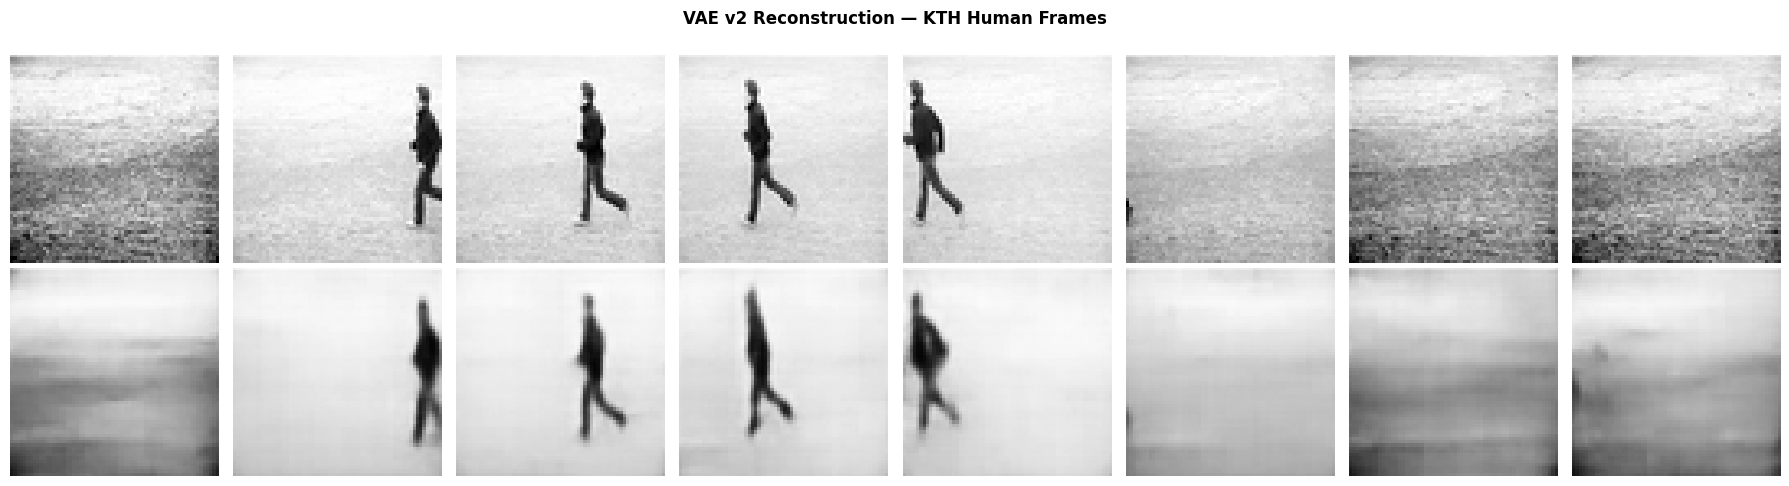

Saved vae_reconstruction.png


In [ ]:
# ── Quick reconstruction check ────────────────────────────────────────────
vae_v2.eval()
with torch.no_grad():
    test_batch = next(iter(test_loader))
    frames_t   = test_batch[:, 0].to(device)
    recon_t, _, _ = vae_v2(frames_t)

frames_t = frames_t.cpu(); recon_t = recon_t.cpu()
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('VAE v2 Reconstruction — KTH Human Frames', fontsize=12, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(frames_t[i, 0], cmap='gray', vmin=0, vmax=1); axes[0, i].axis('off')
    axes[1, i].imshow(recon_t[i, 0],  cmap='gray', vmin=0, vmax=1); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',      fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Reconstructed', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/vae_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved vae_reconstruction.png')

## ✅ Colab 1 Complete

`vae_v2.pth` is now on Hugging Face. Next steps:
- Open **Colab 2** to train ConvLSTM dynamics
- Open **Colab 3** to train Spatial Transformer (can run in parallel)
- Run **Colab 4** after both finish